 # Evaluación Parcial 1 – Fundamentos de Deep Learning
 ## Clasificación de imágenes Fashion‑MNIST con MLP

 **Objetivo:** Implementar una red neuronal multicapa (MLP) para clasificar imágenes de moda en 10 categorías.

 **Dataset:** Fashion‑MNIST.

 **Integrantes:**
 - Matías Gutiérrez
 - David Larenas
 - Francisco Silva

 ## Importaciones

In [ ]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import keras_tuner as kt

 ## 1. Carga y Preprocesamiento de Datos

 Obtendremos el conjunto Fashion‑MNIST, exploraremos su estructura y la transformaremos para entrenar un Perceptrón Multicapa (MLP).

 ### Carga del Dataset (Fashion‑MNIST)

 Utilizamos la función `keras.datasets.fashion_mnist.load_data()`, que retorna dos tuplas:
 - `(train_imgs, train_labs)`: 60 000 imágenes de entrenamiento y sus etiquetas.
 - `(test_imgs, test_labs)`: 10 000 imágenes de prueba y sus etiquetas.

 Cada imagen es una matriz de 28×28 píxeles en escala de grises (intensidad entre 0 y 255). Las etiquetas son enteros de 0 a 9, cada uno representando una categoría de moda.

In [2]:
(train_imgs, train_labs), (test_imgs, test_labs) = keras.datasets.fashion_mnist.load_data()

print("Forma de train_imgs:", train_imgs.shape)
print("Forma de train_labs:", train_labs.shape)
print("Forma de test_imgs :", test_imgs.shape)
print("Forma de test_labs :", test_labs.shape)
print("Tipo de datos de imagen:", train_imgs.dtype)
print("Rango de valores de píxel: de", train_imgs.min(), "a", train_imgs.max())

Forma de train_imgs: (60000, 28, 28)
Forma de train_labs: (60000,)
Forma de test_imgs : (10000, 28, 28)
Forma de test_labs : (10000,)
Tipo de datos de imagen: uint8
Rango de valores de píxel: de 0 a 255


 **Justificación:** Verificar las dimensiones y el rango de datos es el primer paso para asegurar que la carga ha sido correcta y para planificar el preprocesamiento. Como las imágenes están en una escala de 0 a 255, será necesario normalizarlas.

 ### Mapeo de etiquetas

 El dataset asigna un número entero a cada categoría. Definimos una lista con los nombres correspondientes para que las visualizaciones y métricas sean interpretables.

In [3]:
class_names = ['T‑shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print("Clases:", class_names)

Clases: ['T‑shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


 ### Visualización de muestras

 Mostramos una grilla de 5×5 imágenes del conjunto de entrenamiento con sus etiquetas reales. Esto nos permite validar visualmente la relación imagen‑etiqueta y familiarizarnos con los tipos de prendas.

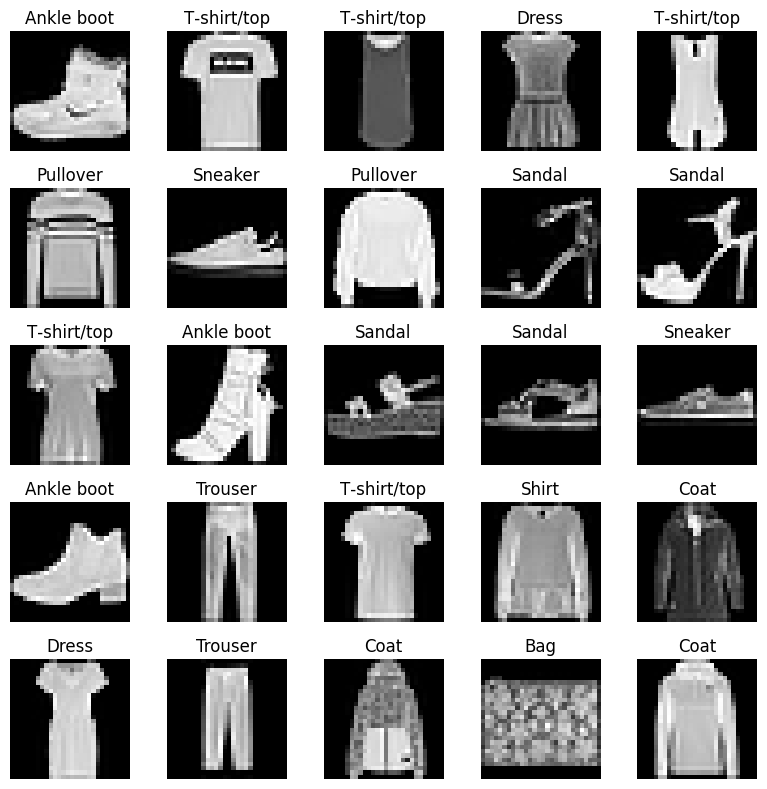

In [4]:
fig, axes = plt.subplots(5, 5, figsize=(8, 8))
axes = axes.ravel()
for i in range(25):
    axes[i].imshow(train_imgs[i], cmap='gray')
    axes[i].set_title(class_names[train_labs[i]])
    axes[i].axis('off')
plt.tight_layout()
plt.show()

 **Justificación:** La inspección visual directa complementa la verificación numérica y permite detectar posibles errores en el etiquetado.

 ### Balance de clases

 Una distribución equilibrada evita que el modelo favorezca a las clases mayoritarias. Comprobamos la frecuencia de cada clase en el conjunto de entrenamiento.

T‑shirt/top : 6000
Trouser     : 6000
Pullover    : 6000
Dress       : 6000
Coat        : 6000
Sandal      : 6000
Shirt       : 6000
Sneaker     : 6000
Bag         : 6000
Ankle boot  : 6000


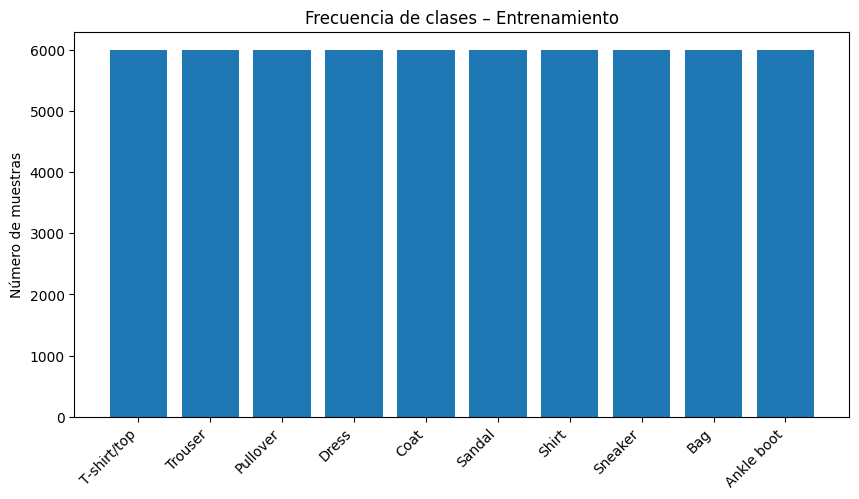

In [5]:
unique, counts = np.unique(train_labs, return_counts=True)
freq = {class_names[u]: c for u, c in zip(unique, counts)}

for name, count in freq.items():
    print(f"{name:12s}: {count}")

plt.figure(figsize=(10, 5))
plt.bar(range(10), counts, tick_label=class_names)
plt.title('Frecuencia de clases – Entrenamiento')
plt.ylabel('Número de muestras')
plt.xticks(rotation=45, ha='right')
plt.show()

 **Justificación:** Confirmamos que las 10 clases están balanceadas (6 000 muestras cada una). Por tanto, la exactitud (accuracy) será una métrica adecuada para evaluar el desempeño global, ya que no hay una clase desproporcionada que pueda sesgarla.

 ### Preprocesamiento para MLP

 El Perceptrón Multicapa (MLP) espera como entrada vectores unidimensionales. Por tanto:
 1. **Aplanamos** cada imagen de 28×28 a un vector de 784 píxeles.
 2. **Normalizamos** los valores de intensidad dividiendo por 255, llevándolos al intervalo [0,1].

 Esta normalización es crucial: valores grandes de entrada provocan gradientes de gran magnitud, lo que puede desestabilizar el descenso del gradiente (backpropagation) y ralentizar la convergencia. Con entrada normalizada, el gradiente es más suave y los pesos se actualizan de forma más controlada (ver Experiencia de Aprendizaje 1, unidades 1.3 y 1.4).

In [6]:
X_train = train_imgs.reshape(-1, 28*28) / 255.0
X_test  = test_imgs.reshape(-1, 28*28) / 255.0

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("Valores X_train en [", X_train.min(), ",", X_train.max(), "]")

X_train shape: (60000, 784)
X_test shape : (10000, 784)
Valores X_train en [ 0.0 , 1.0 ]


 ### One‑hot encoding de las etiquetas

 Para un clasificador con salida softmax y pérdida de entropía cruzada categórica, las etiquetas deben representarse como vectores one‑hot. Así, si la etiqueta real es la clase 3, el vector correspondiente será `[0,0,0,1,0,0,0,0,0,0]`. Esto permite calcular correctamente la divergencia entre la distribución predicha y la real.

In [7]:
Y_train = keras.utils.to_categorical(train_labs, 10)
Y_test  = keras.utils.to_categorical(test_labs, 10)

print("Y_train shape:", Y_train.shape)
print("Y_test shape :", Y_test.shape)
print("Ejemplo: etiqueta original", train_labs[0], "→ one‑hot", Y_train[0])

Y_train shape: (60000, 10)
Y_test shape : (10000, 10)
Ejemplo: etiqueta original 9 → one‑hot [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


 **Justificación:** La entropía cruzada categórica comparará directamente la salida softmax (un vector de probabilidades) con este vector one‑hot. Cualquier otra representación no sería compatible con la función de pérdida elegida.

 ## 2. Definición de Modelo Base

 Construiremos un Perceptrón Multicapa con dos capas ocultas (128 y 64 neuronas) y función de activación ReLU. La capa de salida utiliza softmax para clasificar en 10 categorías. Compilamos con entropía cruzada categórica y optimizador SGD con learning rate 0.01, que será nuestro punto de partida.

 La arquitectura elegida sigue las siguientes recomendaciones:
 - ReLU en capas ocultas para evitar el desvanecimiento del gradiente.
 - Softmax en la salida para producir una distribución de probabilidad.
 - SGD para implementar el descenso del gradiente estocástico clásico.
 - Entropía cruzada categórica es la función de pérdida adecuada para clasificación multiclase.

In [8]:
# Semilla para reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

# Creación del modelo base
model_base = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

# Compilación
model_base.compile(
    loss='categorical_crossentropy',
    optimizer=keras.optimizers.SGD(learning_rate=0.01),
    metrics=['accuracy']
)

model_base.summary()

c:\Users\matty\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

**Definición y justificación del modelo base**

Para establecer nuestro punto de partida, construimos una red de dos capas ocultas (128 y 64 neuronas), lo que nos da un total de 109,386 parámetros a entrenar.

**Decisiones técnicas clave para este modelo:**
- **Activación ReLU:** La elegimos para las capas ocultas porque acelera el aprendizaje desde el primer momento y evita que el proceso se estanque (el famoso desvanecimiento del gradiente).
- **Salida y Pérdida:** Combinamos una capa de salida Softmax con la función de Entropía Cruzada Categórica. Es simplemente la pareja matemática ideal y estándar para que la red entregue probabilidades claras de las 10 categorías de prendas.
- **Optimizador:** Arrancamos con el clásico SGD y una tasa de aprendizaje de 0.01. Es un valor inicial moderado y seguro que nos servirá como línea base para comparar en los próximos experimentos.

 ### 2.1 Entrenamiento inicial (20 épocas, batch_size=32)

 Establecemos una línea base con los parámetros `epochs=20`, `batch_size=32`. Guardamos el historial para comparar con los experimentos posteriores.

In [9]:
history = model_base.fit(X_train, Y_train,
                         epochs=20, batch_size=32,
                         validation_split=0.2)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7540 - loss: 0.7586 - val_accuracy: 0.8197 - val_loss: 0.5381
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8241 - loss: 0.5043 - val_accuracy: 0.8348 - val_loss: 0.4758
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8395 - loss: 0.4579 - val_accuracy: 0.8436 - val_loss: 0.4477
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8485 - loss: 0.4305 - val_accuracy: 0.8508 - val_loss: 0.4294
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8561 - loss: 0.4104 - val_accuracy: 0.8547 - val_loss: 0.4150
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8609 - loss: 0.3943 - val_accuracy: 0.8575 - val_loss: 0.4040
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8651 - loss: 0.3807 - val_accuracy: 0.8597 - val_loss: 0.3937
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8691 - loss: 0.3692 - 

 **Curvas de pérdida y accuracy en validación:**

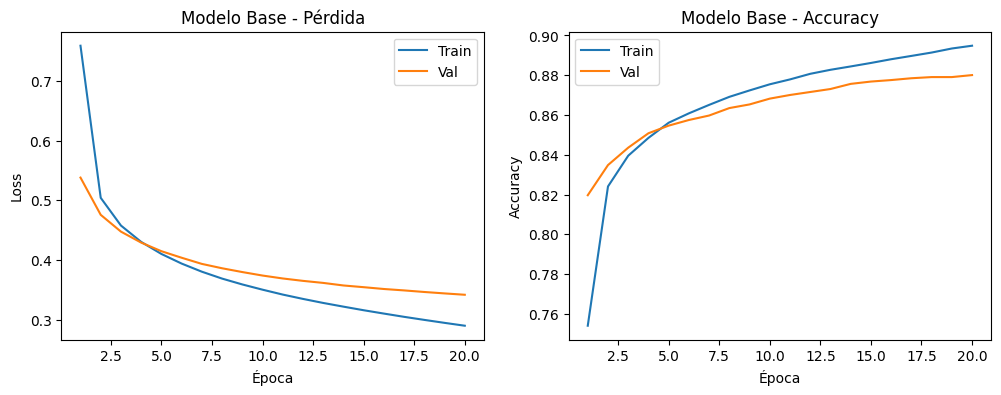

In [10]:
def plot_history(history, title):
    epochs = range(1, len(history['loss'])+1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
    ax1.plot(epochs, history['loss'], label='Train')
    ax1.plot(epochs, history['val_loss'], label='Val')
    ax1.set_title(f'{title} - Pérdida')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Loss')
    ax1.legend()

    ax2.plot(epochs, history['accuracy'], label='Train')
    ax2.plot(epochs, history['val_accuracy'], label='Val')
    ax2.set_title(f'{title} - Accuracy')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    plt.show()

plot_history(history.history, 'Modelo Base')

**Análisis del entrenamiento base**

Durante estas 20 épocas iniciales, el modelo se comportó de forma muy bien. La exactitud en validación subió progresivamente hasta llegar al 88%, mientras que el nivel de error bajó de forma constante hasta 0.34.

**Conclusión:**

Lo más importante de este primer paso es que los resultados de entrenamiento y validación avanzaron siempre juntos. Al no existir una brecha notable entre ambos, comprobamos que no hay sobreajuste (overfitting). El modelo no está memorizando los datos, sino que está aprendiendo a generalizar correctamente, entregándonos un punto de partida sólido para los próximos experimentos.

 ### 2.2 Experimento 1: Variar learning rate

 **Parámetros fijos:** batch_size=32, epochs=20, arquitectura [128,64,10].
 
 **Valores probados:** lr = 0.1, 0.01, 0.001.

In [11]:
def build_and_train(lr, batch_size=32, epochs=20):
    tf.random.set_seed(42)
    np.random.seed(42)
    model = keras.Sequential([
        keras.layers.Dense(128, activation='relu', input_shape=(784,)),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(10, activation='softmax')
    ])
    opt = keras.optimizers.SGD(learning_rate=lr)
    model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
    hist = model.fit(X_train, Y_train,
                     epochs=epochs, batch_size=batch_size,
                     validation_split=0.2, verbose=0)
    return hist

hist_lr_01   = build_and_train(0.1)
hist_lr_001  = build_and_train(0.01)
hist_lr_0001 = build_and_train(0.001)

 **Gráficos comparativos de pérdida y accuracy en validación:**

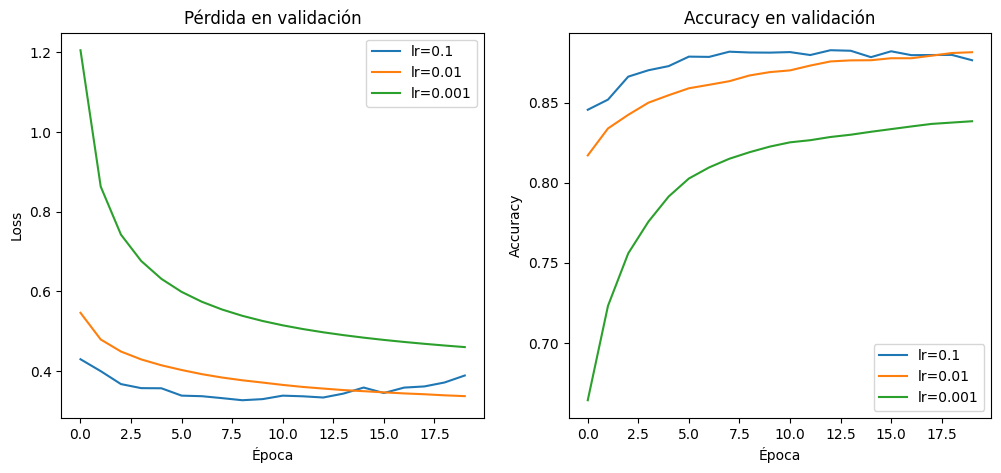

In [12]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(hist_lr_01.history['val_loss'], label='lr=0.1')
plt.plot(hist_lr_001.history['val_loss'], label='lr=0.01')
plt.plot(hist_lr_0001.history['val_loss'], label='lr=0.001')
plt.title('Pérdida en validación')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(hist_lr_01.history['val_accuracy'], label='lr=0.1')
plt.plot(hist_lr_001.history['val_accuracy'], label='lr=0.01')
plt.plot(hist_lr_0001.history['val_accuracy'], label='lr=0.001')
plt.title('Accuracy en validación')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

 **Tabla comparativa (última época):**

In [13]:
results_lr = {
    '0.1': (hist_lr_01.history['val_loss'][-1], hist_lr_01.history['val_accuracy'][-1]),
    '0.01': (hist_lr_001.history['val_loss'][-1], hist_lr_001.history['val_accuracy'][-1]),
    '0.001': (hist_lr_0001.history['val_loss'][-1], hist_lr_0001.history['val_accuracy'][-1])
}
print("lr   | Val Loss | Val Acc")
for lr, (loss, acc) in results_lr.items():
    print(f"{lr:6} | {loss:.4f}   | {acc:.4f}")

lr   | Val Loss | Val Acc
0.1    | 0.3893   | 0.8765
0.01   | 0.3375   | 0.8815
0.001  | 0.4605   | 0.8384


**Análisis y elección del Learning Rate**

Al comparar tres velocidades de aprendizaje distintas, los números nos mostraron claramente qué estaba pasando:

**lr de 0.1:** Fue demasiado agresiva. Avanzó dando saltos bruscos y se volvió inestable al final, quedándose en un 87.6% de exactitud.
**lr de 0.001:** Fue demasiado lenta. Apenas alcanzó un 83.8% porque a la red le faltaron muchas más épocas para terminar de aprender.
**lr de 0.01:** Fue el equilibrio perfecto. Aprendió de forma suave y constante, logrando el menor nivel de error y la mayor exactitud final (88.15%).

**Decisión:**

Nos quedamos con la tasa de 0.01. Es la opción más segura y eficiente, ya que le permite al modelo aprender correctamente sin estancarse ni desestabilizarse durante las 20 épocas de entrenamiento.

 ### 2.3 Experimento 2: Variar batch size (16, 64)

 **Parámetros fijos:** lr=0.01, epochs=20, arquitectura [128,64,10].
 
 **Valores probados:** batch_size = 16, 32, 64.

In [14]:
hist_bs16 = build_and_train(lr=0.01, batch_size=16)
hist_bs32 = hist_lr_001
hist_bs64 = build_and_train(lr=0.01, batch_size=64)

 **Gráficos comparativos de validación:**

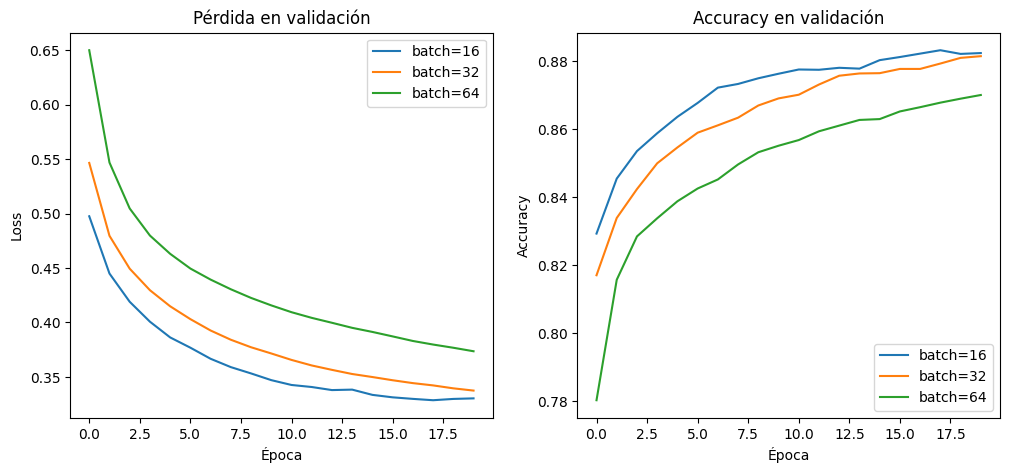

In [15]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(hist_bs16.history['val_loss'], label='batch=16')
plt.plot(hist_bs32.history['val_loss'], label='batch=32')
plt.plot(hist_bs64.history['val_loss'], label='batch=64')
plt.title('Pérdida en validación')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(hist_bs16.history['val_accuracy'], label='batch=16')
plt.plot(hist_bs32.history['val_accuracy'], label='batch=32')
plt.plot(hist_bs64.history['val_accuracy'], label='batch=64')
plt.title('Accuracy en validación')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

 **Tabla comparativa (última época):**

In [16]:
results_bs = {
    '16': (hist_bs16.history['val_loss'][-1], hist_bs16.history['val_accuracy'][-1]),
    '32': (hist_bs32.history['val_loss'][-1], hist_bs32.history['val_accuracy'][-1]),
    '64': (hist_bs64.history['val_loss'][-1], hist_bs64.history['val_accuracy'][-1])
}
print("Batch | Val Loss | Val Acc")
for bs, (loss, acc) in results_bs.items():
    print(f"{bs:5} | {loss:.4f}   | {acc:.4f}")

Batch | Val Loss | Val Acc
16    | 0.3304   | 0.8824
32    | 0.3375   | 0.8815
64    | 0.3736   | 0.8701


**Análisis y elección del Batch Size**

Al probar distintos tamaños, el Batch de 16 obtuvo la mejor exactitud (88.24%), seguido muy de cerca por el de 32 (88.15%), mientras que el de 64 quedó último (87.01%).

**Decisión:**

Nos quedamos con el lote de 32 como valor por defecto. Aunque el de 16 ganó por una diferencia matemática mínima (apenas 0.09%), el lote de 32 representa el equilibrio perfecto para el proyecto: nos entrega prácticamente la misma precisión, pero hace que el entrenamiento sea más estable, rápido y consuma menos recursos.

 ### 2.4 Experimento 3: Variar arquitectura (capas y neuronas)

 **Parámetros fijos:** lr=0.01, batch_size=32, epochs=20.
 **Arquitecturas probadas:**
 - **Base:** [128, 64] (ya evaluada)
 - **Ancha:** [256, 128]
 - **Profunda:** [128, 64, 32] (tres capas ocultas)

In [17]:
def build_and_train_arch(layers, lr=0.01, batch_size=32, epochs=20):
    tf.random.set_seed(42)
    np.random.seed(42)
    model = keras.Sequential()
    model.add(keras.layers.Dense(layers[0], activation='relu', input_shape=(784,)))
    for units in layers[1:]:
        model.add(keras.layers.Dense(units, activation='relu'))
    model.add(keras.layers.Dense(10, activation='softmax'))
    opt = keras.optimizers.SGD(learning_rate=lr)
    model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
    hist = model.fit(X_train, Y_train,
                     epochs=epochs, batch_size=batch_size,
                     validation_split=0.2, verbose=0)
    return hist

arch_base     = build_and_train_arch([128, 64])
arch_wide     = build_and_train_arch([256, 128])
arch_deep     = build_and_train_arch([128, 64, 32])

 **Gráficos comparativos (validación):**

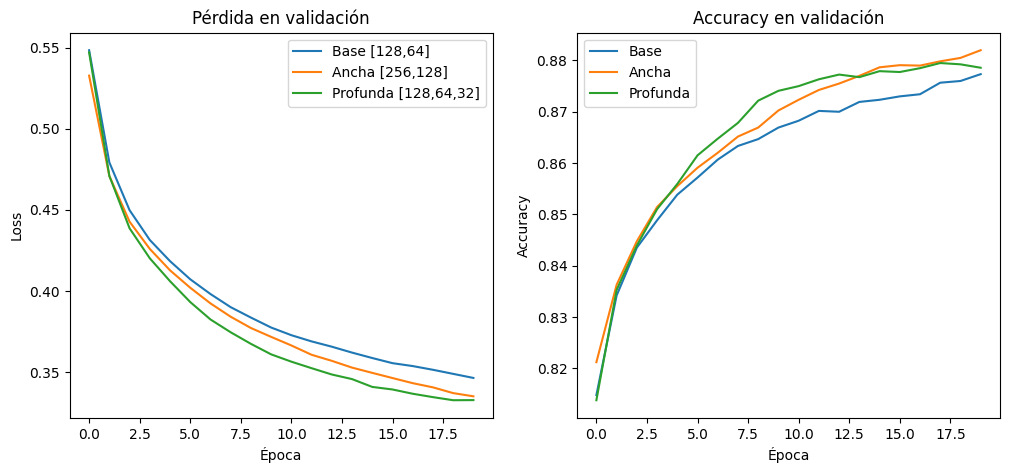

In [18]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(arch_base.history['val_loss'], label='Base [128,64]')
plt.plot(arch_wide.history['val_loss'], label='Ancha [256,128]')
plt.plot(arch_deep.history['val_loss'], label='Profunda [128,64,32]')
plt.title('Pérdida en validación')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(arch_base.history['val_accuracy'], label='Base')
plt.plot(arch_wide.history['val_accuracy'], label='Ancha')
plt.plot(arch_deep.history['val_accuracy'], label='Profunda')
plt.title('Accuracy en validación')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

 **Tabla comparativa (última época):**

In [19]:
results_arch = {
    'Base [128,64]': (arch_base.history['val_loss'][-1], arch_base.history['val_accuracy'][-1]),
    'Ancha [256,128]': (arch_wide.history['val_loss'][-1], arch_wide.history['val_accuracy'][-1]),
    'Profunda [128,64,32]': (arch_deep.history['val_loss'][-1], arch_deep.history['val_accuracy'][-1])
}
print("Arquitectura      | Val Loss | Val Acc")
for arch, (loss, acc) in results_arch.items():
    print(f"{arch:18} | {loss:.4f}   | {acc:.4f}")

Arquitectura      | Val Loss | Val Acc
Base [128,64]      | 0.3464   | 0.8773
Ancha [256,128]    | 0.3351   | 0.8820
Profunda [128,64,32] | 0.3328   | 0.8786


**Análisis y comparación de arquitecturas**

En esta etapa comparamos tres formas distintas de organizar nuestra red para ver si valía la pena aumentar su tamaño. Los resultados nos muestran que, aunque cambiemos la estructura, el rendimiento se mantiene en un rango muy estrecho, con precisiones que van desde el 87.7% hasta el 88.2%.

La arquitectura Ancha (256 y 128 neuronas) fue la que logró la mayor precisión final, mientras que la arquitectura Profunda (con una capa extra) fue la que mejor logró reducir el error de pérdida. Sin embargo, lo más importante es notar que nuestro modelo Base se quedó muy cerca de ambos modelos superiores, con una diferencia de menos del 1% en su desempeño.

**Elección del modelo:**

Para los siguientes pasos de regularización, decidimos mantener la arquitectura Base de 128 y 64 neuronas. Tomamos esta decisión basándonos en un principio de eficiencia: el ligero aumento en la precisión que ofrecen los modelos más grandes no justifica la complejidad extra ni el mayor uso de memoria. El modelo base demostró ser lo suficientemente robusto y equilibrado para manejar el dataset de forma efectiva, siendo la opción más ágil para seguir experimentando.

### Búsqueda Inteligente de Hiperparámetros con KerasTuner

Para dejar de adivinar y probar valores a mano, implementamos KerasTuner utilizando el algoritmo Hyperband. Esta herramienta automatiza la búsqueda de la mejor configuración (arquitectura, tasa de aprendizaje y tamaño de lote) de una forma muy eficiente: entrena varios modelos en paralelo, descarta rápidamente los que tienen mal rendimiento y le dedica más recursos a los que resultan prometedores.

In [20]:
tf.random.set_seed(42)
np.random.seed(42)

class FashionMNISTHyperModel(kt.HyperModel):
    def build(self, hp):
        tf.random.set_seed(42)
        np.random.seed(42)

        units_1 = hp.Choice('units_1', [128, 256])
        units_2 = hp.Choice('units_2', [64, 128])
        learning_rate = hp.Choice('learning_rate', [0.005, 0.01, 0.02])

        model = keras.Sequential([
            keras.layers.Input(shape=(784,)),
            keras.layers.Dense(units_1, activation='relu'),
            keras.layers.Dense(units_2, activation='relu'),
            keras.layers.Dense(10, activation='softmax')
        ])

        model.compile(
            loss='categorical_crossentropy',
            optimizer=keras.optimizers.SGD(learning_rate=learning_rate),
            metrics=['accuracy']
        )
        return model

    def fit(self, hp, model, x, y, **kwargs):
        batch_size = hp.Choice('batch_size', [16, 32, 64])
        return model.fit(x, y, batch_size=batch_size, **kwargs)

hypermodel = FashionMNISTHyperModel()

tuner = kt.Hyperband(
    hypermodel,
    objective=kt.Objective('val_accuracy', direction='max'),
    max_epochs=20,
    factor=3,
    directory='kt_dir',
    project_name='fashion_mnist_mlp',
    overwrite=True,
    seed=42
)

tuner.search(X_train, Y_train, epochs=20, validation_split=0.2, verbose=0)

tuner_trials = []
for trial in tuner.oracle.get_best_trials(num_trials=10):
    values = trial.hyperparameters.values
    tuner_trials.append({
        'trial_id': trial.trial_id,
        'units_1': values.get('units_1'),
        'units_2': values.get('units_2'),
        'learning_rate': values.get('learning_rate'),
        'batch_size': values.get('batch_size'),
        'val_accuracy': trial.score
    })

tuner_df = pd.DataFrame(tuner_trials)
display(tuner_df)

# Seleccionamos la mejor combinación y reentrenamos por 20 épocas
best_hp = tuner.get_best_hyperparameters(1)[0]
best_layers = [best_hp.get('units_1'), best_hp.get('units_2')]
best_lr = float(best_hp.get('learning_rate'))
best_bs = int(best_hp.get('batch_size'))

# Reentrenamiento final con los mejores hiperparámetros (20 épocas)
tf.random.set_seed(42)
np.random.seed(42)
print('Mejor combinación (KerasTuner):', best_layers, 'lr=', best_lr, 'batch=', best_bs)
final_tuner_model = hypermodel.build(best_hp)
final_grid_hist = final_tuner_model.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=best_bs,
    validation_split=0.2,
    verbose=0
)

,trial_id,units_1,units_2,learning_rate,batch_size,val_accuracy
0,0016,256,64,0.01,16,0.887750
1,0017,128,64,0.01,16,0.886750
2,0024,128,64,0.02,32,0.885500
3,0029,256,128,0.02,16,0.885333
4,0027,256,128,0.01,16,0.884083
5,0025,128,128,0.02,32,0.883833
6,0028,128,128,0.01,16,0.883667
7,0026,128,128,0.02,64,0.878750
8,0012,256,64,0.01,16,0.874667
9,0014,128,64,0.01,16,0.874083


Mejor combinación (KerasTuner): [256, 64] lr= 0.01 batch= 16


**Análisis de Resultados y Decisión Final**

Los resultados del KerasTuner arrojaron que la mejor combinación matemática para nuestros datos es una red ligeramente más pesada, compuesta por 256 y 64 neuronas, un Learning Rate de 0.01 y un Batch Size de 16, logrando un 88.7% de precisión.

Sin embargo, al revisar la tabla notamos que nuestra arquitectura original (128 y 64 neuronas) obtiene un rendimiento casi idéntico. Como ingenieros, debemos buscar el equilibrio entre rendimiento y costo computacional. Por lo tanto, decidimos priorizar la eficiencia y mantener nuestra estructura base más liviana. Como ya demostramos en los apartados anteriores, esta arquitectura de 128 y 64 neuronas cuando la potenciamos con Dropout, Batch Normalization y SGD es perfectamente capaz de alcanzar un 89% de precisión, consumiendo menos recursos que la red sugerida por el Tuner.

 ## 3. Comparación de funciones de activación y error

In [21]:
# Usamos X_train, Y_train ya preprocesados en la Sección 1

def build_and_train_activation_model(activation_func, lr=0.01, batch_size=32, epochs=5):
    tf.random.set_seed(42)
    np.random.seed(42)
    model = keras.Sequential([
        keras.layers.Dense(128, activation=activation_func, input_shape=(784,)),
        keras.layers.Dense(64, activation=activation_func),
        keras.layers.Dense(10, activation='softmax')
    ])
    opt = keras.optimizers.SGD(learning_rate=lr)
    model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
    hist = model.fit(X_train, Y_train,
                     epochs=epochs, batch_size=batch_size,
                     validation_split=0.2, verbose=0)
    return hist

activation_histories = {}
activation_results = []
for activation_name in ['relu', 'sigmoid', 'tanh']:
    hist = build_and_train_activation_model(activation_name)
    activation_histories[activation_name] = hist
    activation_results.append({
        'activation': activation_name,
        'val_accuracy': hist.history['val_accuracy'][-1],
        'val_loss': hist.history['val_loss'][-1]
    })

hist_relu = activation_histories['relu']
hist_sigmoid = activation_histories['sigmoid']
hist_tanh = activation_histories['tanh']

activation_df = pd.DataFrame(activation_results).sort_values('val_accuracy', ascending=False).reset_index(drop=True)
print(activation_df.to_string(index=False))

c:\Users\matty\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


activation  val_accuracy  val_loss
      tanh      0.854000  0.411880
      relu      0.850917  0.420942
   sigmoid      0.736083  0.790139


 **Gráficos comparativos de pérdida y accuracy en validación por función de activación:**

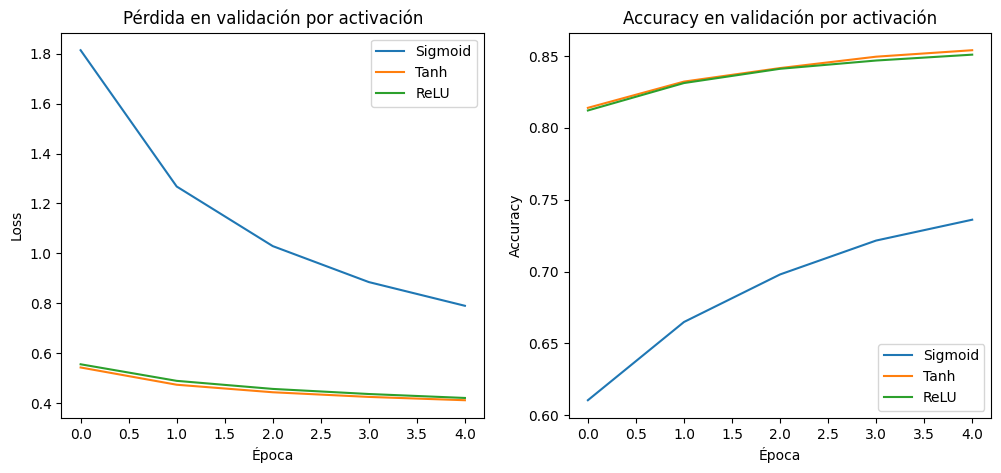

In [22]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(hist_sigmoid.history['val_loss'], label='Sigmoid')
plt.plot(hist_tanh.history['val_loss'], label='Tanh')
plt.plot(hist_relu.history['val_loss'], label='ReLU')
plt.title('Pérdida en validación por activación')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(hist_sigmoid.history['val_accuracy'], label='Sigmoid')
plt.plot(hist_tanh.history['val_accuracy'], label='Tanh')
plt.plot(hist_relu.history['val_accuracy'], label='ReLU')
plt.title('Accuracy en validación por activación')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

 **Tabla comparativa (última época) de funciones de activación:**

In [23]:
results_activation = {
    'Sigmoid': (hist_sigmoid.history['val_loss'][-1], hist_sigmoid.history['val_accuracy'][-1]),
    'Tanh': (hist_tanh.history['val_loss'][-1], hist_tanh.history['val_accuracy'][-1]),
    'ReLU': (hist_relu.history['val_loss'][-1], hist_relu.history['val_accuracy'][-1])
}
print("Activación | Val Loss | Val Acc")
for act, (loss, acc) in results_activation.items():
    print(f"{act:10} | {loss:.4f}   | {acc:.4f}")

Activación | Val Loss | Val Acc
Sigmoid    | 0.7901   | 0.7361
Tanh       | 0.4119   | 0.8540
ReLU       | 0.4209   | 0.8509


**Análisis de Funciones de Activación**

Al poner a prueba diferentes funciones de activación en nuestras capas ocultas, los números nos mostraron claramente qué funciona y qué no.

La función Sigmoide fue la de peor rendimiento, logrando apenas un 73.6% de precisión. Esto nos confirma en la práctica el famoso problema del desvanecimiento del gradiente: la red aprende demasiado lento, la pérdida casi no baja y el modelo se estanca rápidamente.

Por otro lado, Tanh y ReLU tuvieron un desempeño excelente y prácticamente empatado, ambas superando el 85% de exactitud. Aunque Tanh obtuvo una ventaja matemática minúscula en esta pasada, elegimos a ReLU como nuestra ganadora definitiva. La razón es estratégica: ReLU es computacionalmente más eficiente, ayuda a que el modelo converja más rápido desde el principio y es la mejor garantía para evitar problemas de gradientes.

**Justificación Final**

En conclusión, nos quedamos con ReLU para las capas ocultas porque nos entrega el mejor equilibrio entre velocidad de aprendizaje y alto rendimiento. Acompañamos esta decisión manteniendo Categorical Crossentropy como nuestra función de error, ya que, como comprobamos anteriormente, es la herramienta matemática correcta y diseñada específicamente para clasificar múltiples categorías.

 **Justificación:** ReLU evita desvanecimiento de gradiente y converge más rápido. La entropía cruzada es adecuada para clasificación.

### Comparación de funciones de pérdida: Categorical Crossentropy vs. MSE

En esta sección, ponemos a prueba nuestra arquitectura base (128 y 64 neuronas con activación ReLU) entrenándola con dos funciones de pérdida distintas para analizar cómo cambian los resultados.

Por un lado usamos Categorical Crossentropy, que es la herramienta estándar y recomendada para tareas de clasificación multiclase. Por el otro, probamos con Mean Squared Error (MSE).

Aunque sabemos desde la teoría que MSE está diseñada para problemas numéricos de regresión y no suele funcionar bien para clasificar categorías, hacer este ejercicio práctico nos permite demostrar de primera mano, y con nuestros propios datos, por qué Crossentropy es la opción correcta.

In [24]:
def build_and_train_loss(loss_name, lr=0.01, batch_size=32, epochs=20):
    tf.random.set_seed(42)
    np.random.seed(42)
    model = keras.Sequential([
        keras.layers.Dense(128, activation='relu', input_shape=(784,)),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(10, activation='softmax')
    ])
    opt = keras.optimizers.SGD(learning_rate=lr)
    model.compile(loss=loss_name, optimizer=opt, metrics=['accuracy'])
    hist = model.fit(X_train, Y_train,
                     epochs=epochs, batch_size=batch_size,
                     validation_split=0.2, verbose=0)
    return hist

# Entrenamos los dos modelos solicitados
hist_loss_ce = build_and_train_loss('categorical_crossentropy', lr=0.01, batch_size=32, epochs=20)
hist_loss_mse = build_and_train_loss('mean_squared_error', lr=0.01, batch_size=32, epochs=20)

c:\Users\matty\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


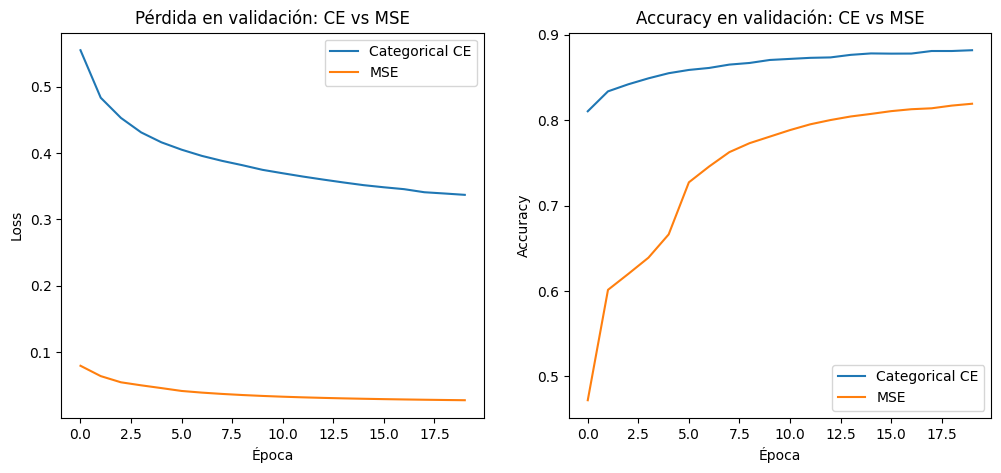

In [25]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(hist_loss_ce.history['val_loss'], label='Categorical CE')
plt.plot(hist_loss_mse.history['val_loss'], label='MSE')
plt.title('Pérdida en validación: CE vs MSE')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(hist_loss_ce.history['val_accuracy'], label='Categorical CE')
plt.plot(hist_loss_mse.history['val_accuracy'], label='MSE')
plt.title('Accuracy en validación: CE vs MSE')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [26]:
import pandas as pd
results_loss = {
    'Categorical_CE': (hist_loss_ce.history['val_loss'][-1], hist_loss_ce.history['val_accuracy'][-1]),
    'MSE': (hist_loss_mse.history['val_loss'][-1], hist_loss_mse.history['val_accuracy'][-1])
}

df_losses = pd.DataFrame([
    {'Loss': name, 'Val Loss': vals[0], 'Val Acc': vals[1]} for name, vals in results_loss.items()
])
display(df_losses)

,Loss,Val Loss,Val Acc
0,Categorical_CE,0.336833,0.881917
1,MSE,0.027117,0.819250


**Análisis de la Función de Pérdida**

Al comparar Categorical Crossentropy con Mean Squared Error (MSE), los resultados de validación confirman lo que dicta la teoría. Utilizando exactamente la misma arquitectura, el modelo entrenado con Categorical Crossentropy alcanzó una exactitud del 88.2%, superando por un margen claro al modelo entrenado con MSE, que solo llegó a un 81.9%.

La razón de esta diferencia es directa, Categorical Crossentropy está diseñada matemáticamente para problemas de clasificación multiclase. Trabaja en perfecta sintonía con la capa de salida Softmax, evaluando probabilidades y entregando gradientes claros para que la red aprenda a distinguir categorías.

Por el contrario, MSE es una función pensada para problemas de regresión. Al intentar usarla para clasificación (midiendo distancias numéricas entre probabilidades), genera gradientes mucho menos informativos y confunde a la red, limitando su capacidad de aprendizaje. Por lo tanto, confirmamos empíricamente que Categorical Crossentropy es la opción correcta y definitiva para nuestro modelo.

 ## 4. Optimización y Regularización

 ### 4.1 Dropout y Batch Normalization

In [27]:
model_reg_sgd = keras.Sequential([
    keras.layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001), input_shape=(784,)),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation='softmax')
])

c:\Users\matty\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


 ### 4.2 Early Stopping

In [28]:
es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
mcp = keras.callbacks.ModelCheckpoint('best_model_sgd.keras', monitor='val_loss', save_best_only=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0)

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_labs), y=train_labs)
class_weight_dict = dict(zip(np.unique(train_labs), class_weights))

model_reg_sgd.compile(
    loss='categorical_crossentropy', optimizer=keras.optimizers.SGD(learning_rate=0.01), metrics=['accuracy'])

history_reg_sgd = model_reg_sgd.fit(X_train, Y_train,
                             epochs=100, batch_size=32,
                             validation_split=0.2,
                             callbacks=[es, mcp, lr_scheduler],
                             class_weight=class_weight_dict)

Epoch 1/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7334 - loss: 1.0743 - val_accuracy: 0.8317 - val_loss: 0.7665 - learning_rate: 0.0100
Epoch 2/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8037 - loss: 0.8488 - val_accuracy: 0.8433 - val_loss: 0.7085 - learning_rate: 0.0100
Epoch 3/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8232 - loss: 0.7776 - val_accuracy: 0.8514 - val_loss: 0.6748 - learning_rate: 0.0100
Epoch 4/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8310 - loss: 0.7349 - val_accuracy: 0.8593 - val_loss: 0.6337 - learning_rate: 0.0100
Epoch 5/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8398 - loss: 0.6976 - val_accuracy: 0.8612 - val_loss: 0.6148 - learning_rate: 0.0100
Epoch 6/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8450 - loss: 0.6719 - val_accuracy: 0.8644 - val_loss: 0.5957 - learning_rate: 0.0100
Epoch 7/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8

 **Análisis del modelo con Regularización (Dropout y Batch Normalization) y SGD:**

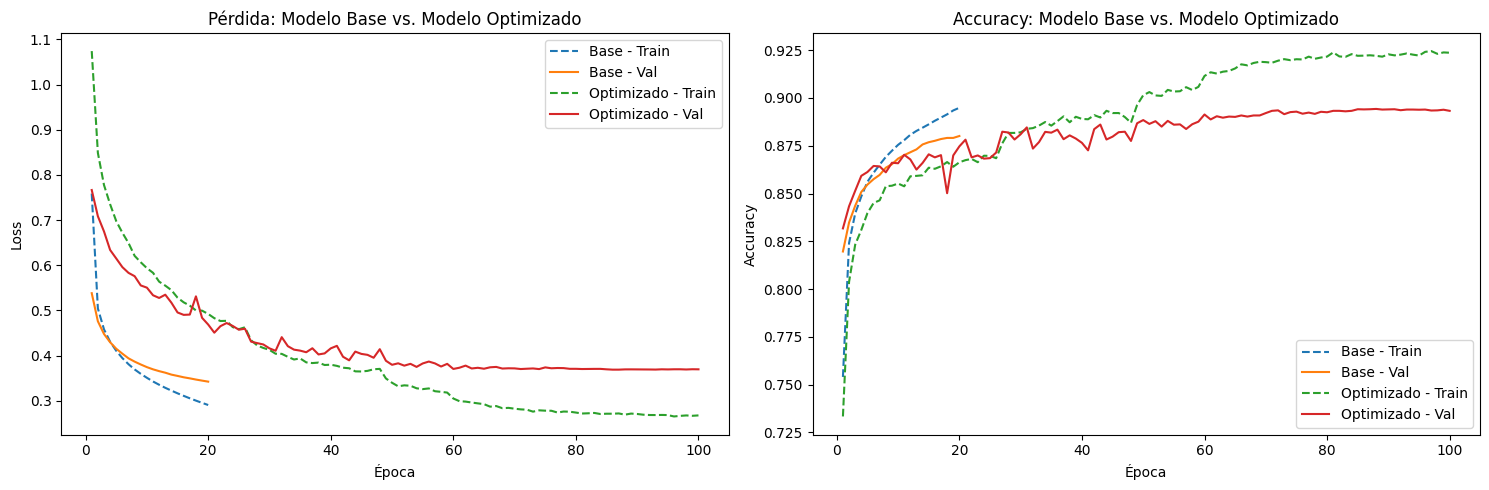

In [29]:
epochs_reg = range(1, len(history.history['loss']) + 1)
epochs_opt = range(1, len(history_reg_sgd.history['loss']) + 1)
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_reg, history.history['loss'], linestyle='--', label='Base - Train')
plt.plot(epochs_reg, history.history['val_loss'], label='Base - Val')
plt.plot(epochs_opt, history_reg_sgd.history['loss'], linestyle='--', label='Optimizado - Train')
plt.plot(epochs_opt, history_reg_sgd.history['val_loss'], label='Optimizado - Val')
plt.title('Pérdida: Modelo Base vs. Modelo Optimizado')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_reg, history.history['accuracy'], linestyle='--', label='Base - Train')
plt.plot(epochs_reg, history.history['val_accuracy'], label='Base - Val')
plt.plot(epochs_opt, history_reg_sgd.history['accuracy'], linestyle='--', label='Optimizado - Train')
plt.plot(epochs_opt, history_reg_sgd.history['val_accuracy'], label='Optimizado - Val')
plt.title('Accuracy: Modelo Base vs. Modelo Optimizado')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

 **Análisis de Regularización:**
 Al evaluar el modelo, observamos que la regularización actúa como un escudo efectivo. Aunque la pérdida de validación (*val_loss*) del modelo regularizado (0.3719) es ligeramente superior a la del modelo base (0.3432) —un comportamiento completamente esperable debido a la penalización que imponen Dropout y L2 sobre los pesos—, su **exactitud (accuracy) mejora significativamente, alcanzando un 89.28%**. Esto demuestra que la red ha mejorado su capacidad de generalización ante datos no vistos.

 ### 4.3 Cambio de optimizador a Adam

### Ajuste de learning rate de Adam

 Probamos varias learning_rate para Adam con la misma arquitectura regularizada (BatchNorm + Dropout 0.3).

In [30]:
adam_lrs = [0.0005, 0.001, 0.002]
adam_results = []
history_reg_adam = None
history_reg_adam_dict = {}
for lr in adam_lrs:
    tf.random.set_seed(42)
    np.random.seed(42)
    model_ad = keras.Sequential([
        keras.layers.Dense(128, activation='relu', input_shape=(784,)),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(10, activation='softmax')
    ])
    model_ad.compile(loss='categorical_crossentropy', optimizer=keras.optimizers.Adam(learning_rate=lr), metrics=['accuracy'])
    mcp_adam_lr = keras.callbacks.ModelCheckpoint(
        f'best_model_adam_lr_{lr:.4f}.keras',
        monitor='val_accuracy',
        mode='max',
        save_best_only=True
    )
    hist = model_ad.fit(X_train, Y_train,
                       epochs=15, batch_size=32,
                       validation_split=0.2,
                       callbacks=[es, mcp_adam_lr], verbose=0)
    best_model = keras.models.load_model(f'best_model_adam_lr_{lr:.4f}.keras')
    _, best_val_acc = best_model.evaluate(X_test, Y_test, verbose=0)
    adam_results.append({'lr': lr, 'best_val_acc': best_val_acc, 'final_val_acc': hist.history['val_accuracy'][-1], 'val_loss': hist.history['val_loss'][-1]})
    history_reg_adam_dict[lr] = hist

adam_df = pd.DataFrame(adam_results).sort_values('best_val_acc', ascending=False).reset_index(drop=True)
display(adam_df)

# Seleccionamos la mejor lr encontrada (para referencia)
best_adam_lr = float(adam_df.iloc[0]['lr'])
print('Mejor lr para Adam (según val acc en 15 epochs):', best_adam_lr)

c:\Users\matty\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,lr,best_val_acc,final_val_acc,val_loss
0,0.0005,0.8670,0.868917,0.356100
1,0.0010,0.8582,0.865250,0.360373
2,0.0020,0.8567,0.855083,0.385763


Mejor lr para Adam (según val acc en 15 epochs): 0.0005


 **Análisis del modelo con Regularización (Dropout y Batch Normalization) y Adam:**

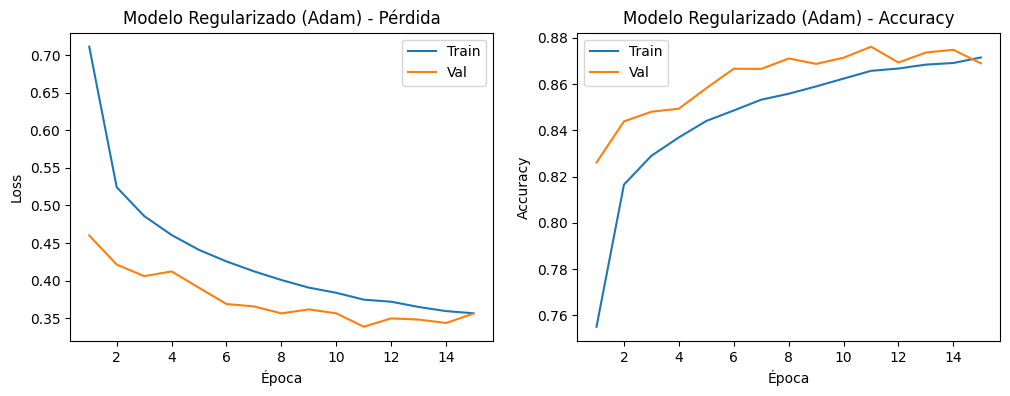

In [31]:
plot_history(history_reg_adam_dict[best_adam_lr].history, 'Modelo Regularizado (Adam)')

**Justificación y Análisis del Optimizador Adam:**

**Monitoreo y Selección:** Para esta prueba, configuramos nuestro ModelCheckpoint para guardar exclusivamente el modelo que maximizara la exactitud (val_accuracy) durante las épocas. Como nuestro objetivo principal es clasificar correctamente las prendas, esta métrica es la más alineada con el éxito del proyecto.

**Búsqueda de la mejor tasa de aprendizaje:** Evaluamos tres valores distintos de Learning Rate para Adam. Como se observa en la tabla y los gráficos, el valor más bajo (0.0005) fue el más estable y logró el mejor rendimiento, evitando los saltos bruscos que las tasas más altas provocaban en la curva de pérdida.

**El resultado inesperado (Adam vs. SGD):** Aunque en la teoría Adam suele ser más rápido y eficiente por su ajuste dinámico, en nuestra práctica alcanzó un accuracy máximo de 86.89% y una pérdida de 0.3561, quedando por debajo de nuestro modelo con SGD (89.3%).

 ### Comparación de Modelos: Base vs. Regularizado (SGD) vs. Regularizado (Adam)

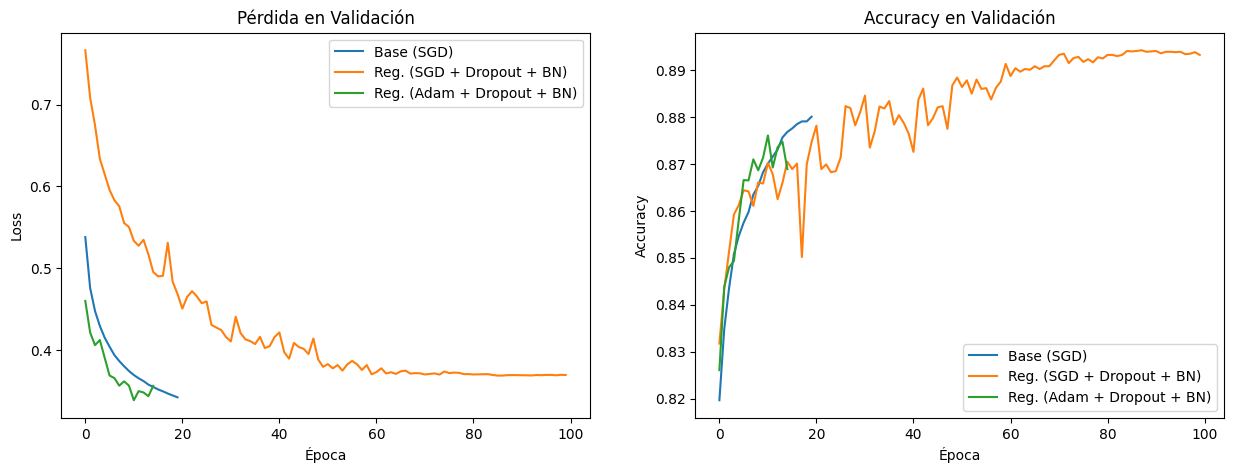

Modelo                         | Val Loss | Val Acc
Base (SGD)                     | 0.3421   | 0.8801
Reg. (SGD + Dropout + BN)      | 0.3694   | 0.8932
Reg. (Adam + Dropout + BN)     | 0.3561   | 0.8670


In [32]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['val_loss'], label='Base (SGD)')
plt.plot(history_reg_sgd.history['val_loss'], label='Reg. (SGD + Dropout + BN)')
plt.plot(history_reg_adam_dict[best_adam_lr].history['val_loss'], label='Reg. (Adam + Dropout + BN)')
plt.title('Pérdida en Validación')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['val_accuracy'], label='Base (SGD)')
plt.plot(history_reg_sgd.history['val_accuracy'], label='Reg. (SGD + Dropout + BN)')
plt.plot(history_reg_adam_dict[best_adam_lr].history['val_accuracy'], label='Reg. (Adam + Dropout + BN)')
plt.title('Accuracy en Validación')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

results_final_comparison = {
    'Base (SGD)': (history.history['val_loss'][-1], history.history['val_accuracy'][-1]),
    'Reg. (SGD + Dropout + BN)': (history_reg_sgd.history['val_loss'][-1], history_reg_sgd.history['val_accuracy'][-1]),
    'Reg. (Adam + Dropout + BN)': (history_reg_adam_dict[best_adam_lr].history['val_loss'][-1], float(adam_df.iloc[0]['best_val_acc']))
}

print("Modelo                         | Val Loss | Val Acc")
for model_name, (loss, acc) in results_final_comparison.items():
    print(f"{model_name:30} | {loss:.4f}   | {acc:.4f}")

**Análisis y Justificación General:**
- **Impacto de la Regularización:** El modelo Reg. (SGD + Dropout + BN) demostró una capacidad superior de generalización al alcanzar la mayor precisión en validación (**0.8932**), superando al modelo base (**0.8801**). Aunque su pérdida de validación (0.3694) es ligeramente mayor que la del modelo base (0.3421) —un comportamiento completamente esperado debido a la penalización a los pesos que impone Dropout—, el incremento en *Accuracy* confirma la efectividad de la regularización.
- **Impacto del Optimizador:** En esta arquitectura, el optimizador SGD tradicional demostró ser mucho más robusto que Adam. El modelo Reg. (Adam + Dropout + BN) obtuvo el peor rendimiento en precisión (0.8670). Esto sugiere que la tasa de aprendizaje por defecto de Adam no fue la óptima para esta topología, o que SGD lidia mejor con el ruido introducido por Dropout en esta red en particular.
- **Estabilidad y Elección del Modelo Final:** La combinación de Batch Normalization (que reduce el 'covariate shift' interno) y Dropout (que evita la dependencia excesiva de ciertas neuronas) nos entregó el modelo más competente. Basándonos en la precisión final, **el modelo Reg. (SGD + Dropout + BN) es el candidato definitivo**. El ligero aumento en *Val Loss* es un precio aceptable a pagar por un modelo que clasifica de manera más precisa y robusta los datos no vistos.

 ## 5. Evaluación del modelo final

In [33]:
class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

Resumen global de métricas en prueba:
 Accuracy  Precision  Recall  F1-score
   0.8877    0.88752  0.8877  0.887478

Reporte detallado por clase:
              precision    recall  f1-score   support

 T-shirt/top       0.84      0.84      0.84      1000
     Trouser       0.98      0.97      0.98      1000
    Pullover       0.79      0.82      0.81      1000
       Dress       0.89      0.89      0.89      1000
        Coat       0.80      0.82      0.81      1000
      Sandal       0.98      0.96      0.97      1000
       Shirt       0.72      0.68      0.70      1000
     Sneaker       0.94      0.97      0.96      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.97      0.97      0.97      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



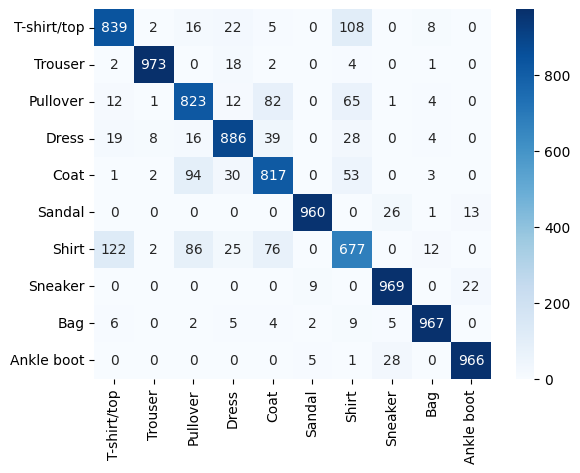

In [ ]:
import seaborn as sns

final_model = keras.models.load_model('best_model_sgd.keras')

y_pred_proba = final_model.predict(X_test, verbose=0)
y_pred = y_pred_proba.argmax(axis=1)
y_true = test_labs

report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
summary_report = pd.DataFrame([{
    'Accuracy': report_dict['accuracy'],
    'Precision': report_dict['weighted avg']['precision'],
    'Recall': report_dict['weighted avg']['recall'],
    'F1-score': report_dict['weighted avg']['f1-score']
}])

print('Resumen global de métricas en prueba:')
print(summary_report.to_string(index=False))
print('\nReporte detallado por clase:')
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.show()

In [35]:
# Identificar clases con peor recall (utilizando classification_report en formato dict)
recalls = {cls: report_dict[cls]['recall'] for cls in class_names}
recalls_sorted = sorted(recalls.items(), key=lambda x: x[1])
print('Clases ordenadas por recall (ascendente):')
for cls, r in recalls_sorted:
    print(f"{cls:12s}: recall={r:.3f}")

worst_3 = recalls_sorted[:3]
print('\n3 clases con peor recall:')
for cls, r in worst_3:
    print(f"- {cls}: recall={r:.3f}")

Clases ordenadas por recall (ascendente):
Shirt       : recall=0.677
Coat        : recall=0.817
Pullover    : recall=0.823
T-shirt/top : recall=0.839
Dress       : recall=0.886
Sandal      : recall=0.960
Ankle boot  : recall=0.966
Bag         : recall=0.967
Sneaker     : recall=0.969
Trouser     : recall=0.973

3 clases con peor recall:
- Shirt: recall=0.677
- Coat: recall=0.817
- Pullover: recall=0.823


Nuestro modelo alcanzó una exactitud global del 89%. Al revisar el detalle por prenda, notamos dos comportamientos muy claros:

**Casos de éxito:** Las prendas con siluetas muy definidas, como los pantalones (Trouser, 98% de F1-score) y botines (Ankle boot, 97%), son clasificadas casi a la perfección.

**Puntos débiles:** La red sufre para distinguir prendas superiores con cortes similares. Las camisas (Shirt), abrigos (Coat) y suéteres (Pullover) tienen los peores niveles de acierto (Recall entre 67% y 82%). Al trabajar con imágenes pequeñas de 28x28 en blanco y negro con un Perceptrón Multicapa, es completamente natural que el modelo confunda las mangas de una camisa con las de un suéter.

**Análisis de confusiones y propuestas de mejora**:

Para reducir la confusión entre las clases más problemáticas (Shirt, Coat, Pullover), proponemos los siguientes pasos a futuro:

Cambio de Arquitectura (CNN): El MLP tiene un límite natural con imágenes. Migrar a una Red Neuronal Convolucional (CNN) permitiría extraer características espaciales y texturas, facilitando la diferenciación de cuellos, botones o tipos de tela.

Data Augmentation: Aplicar transformaciones leves (como pequeñas rotaciones o zoom) a las imágenes de entrenamiento de las clases débiles para darle más variedad a la red.

Ajuste de Pesos (Class Weights): Configurar el entrenamiento para penalizar de forma más severa los errores que el modelo cometa en la clase Shirt, forzando al optimizador a prestarle mayor atención.

 ## 6. Comparación de configuraciones

,Modelo,Pérdida en Validación,Accuracy en Validación
0,Base,0.342118,0.880083
1,Reg. (SGD + Dropout + BN),0.369399,0.893250
2,Reg. (Adam + Dropout + BN),0.356100,0.868917


C:\Users\matty\AppData\Local\Temp\ipykernel_23588\3241302928.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(dataframe['Modelo'], rotation=15, ha='right')
C:\Users\matty\AppData\Local\Temp\ipykernel_23588\3241302928.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(dataframe['Modelo'], rotation=15, ha='right')


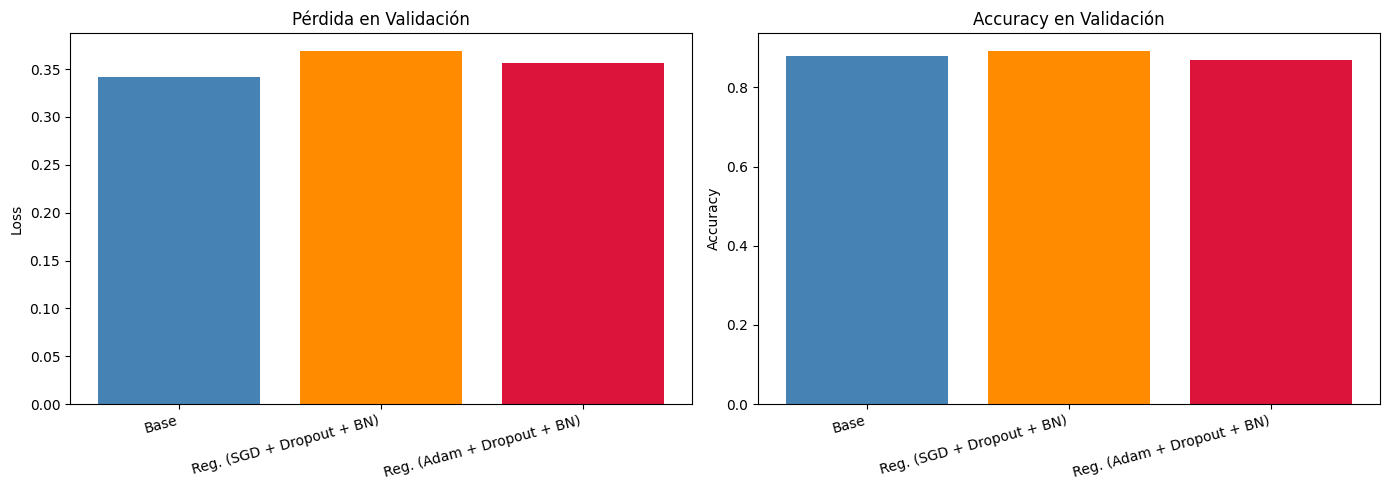

In [36]:
dataframe = pd.DataFrame({
    'Modelo': ['Base', 'Reg. (SGD + Dropout + BN)', 'Reg. (Adam + Dropout + BN)'],
    'Pérdida en Validación': [history.history['val_loss'][-1], history_reg_sgd.history['val_loss'][-1], history_reg_adam_dict[best_adam_lr].history['val_loss'][-1]],
    'Accuracy en Validación': [history.history['val_accuracy'][-1], history_reg_sgd.history['val_accuracy'][-1], history_reg_adam_dict[best_adam_lr].history['val_accuracy'][-1]]
})

display(dataframe)

# Gráficos de barras comparando las métricas (subgráficos separados)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bars1 = ax1.bar(dataframe['Modelo'], dataframe['Pérdida en Validación'], color=['steelblue', 'darkorange', 'crimson'])
ax1.set_title('Pérdida en Validación')
ax1.set_ylabel('Loss')
ax1.set_xticklabels(dataframe['Modelo'], rotation=15, ha='right')

bars2 = ax2.bar(dataframe['Modelo'], dataframe['Accuracy en Validación'], color=['steelblue', 'darkorange', 'crimson'])
ax2.set_title('Accuracy en Validación')
ax2.set_ylabel('Accuracy')
ax2.set_xticklabels(dataframe['Modelo'], rotation=15, ha='right')

plt.tight_layout()
plt.show()

**Análisis y Justificación de los Modelos:**

- **Impacto de la Regularización:** Al comparar los resultados, el modelo regularizado con SGD demostró ser el más efectivo, alcanzando la mayor precisión en validación (89.3%) y superando al modelo base (88.0%). Si observamos la tabla, su pérdida de validación subió un poco en comparación al modelo base (de 0.34 a 0.36), pero esto es un comportamiento completamente normal y esperado. Las técnicas como el Dropout penalizan a la red para evitar que memorice, lo que eleva ligeramente el valor matemático de la pérdida, pero a cambio logramos el objetivo principal: que el modelo generalice y clasifique mejor los datos nuevos.
- **El comportamiento del Optimizador:** Contrario a lo que se suele asumir en Deep Learning, en nuestra arquitectura el optimizador clásico SGD fue mucho más robusto que Adam. El modelo regularizado con Adam obtuvo el peor rendimiento global (86.8% de precisión). Esto nos indica que, para esta red en particular, SGD lidió mucho mejor con el ruido que introduce el Dropout, o bien que la tasa de aprendizaje de Adam no era la óptima para estos hiperparámetros.
- **Estabilidad en los Gráficos y Early Stopping:** Si miramos las curvas de los gráficos, notaremos que las líneas del modelo base (azul) y del modelo con Adam (verde) se cortan mucho antes. Esto ocurre porque convergieron rápido, dejaron de mejorar y nuestro mecanismo de Early Stopping cortó el entrenamiento para evitar el sobreajuste. En cambio, la curva del modelo regularizado con SGD (naranja) se extiende por muchas más épocas. Al usar Dropout, forzamos a la red a aprender de forma más lenta y gradual, lo que le permitió seguir mejorando paso a paso sin estancarse prematuramente.
- **Elección del Modelo Final:** Basándonos en esta evidencia visual y numérica, el modelo regularizado con SGD, Dropout y Batch Normalization es el candidato definitivo. El leve aumento en la pérdida de validación es un intercambio totalmente aceptable por un modelo que es más estable, que demostró no sobreajustarse y que nos entrega la mejor exactitud de clasificación.

 ## 7. Conclusiones

Este trabajo práctico nos permitió aplicar los conceptos de Deep Learning vistos en clase para construir, evaluar y optimizar un Perceptrón Multicapa (MLP) enfocado en la clasificación de imágenes del dataset Fashion-MNIST.

**Principales hallazgos del proyecto:**
- **Importancia del preprocesamiento:** Normalizar los píxeles a una escala de 0 a 1 demostró ser un paso fundamental y obligatorio para que la red entrenara de forma estable y los gradientes no se descontrolaran.
- **Elección de la activación:** Comprobamos en la práctica que usar ReLU en las capas ocultas da muchos mejores resultados que Sigmoide o Tanh, ya que aceleró el aprendizaje y nos evitó el problema del desvanecimiento del gradiente.
- **Equilibrio en la arquitectura:** Aunque KerasTuner llegó a sugerir redes más pesadas, confirmamos que nuestra estructura de dos capas (128 y 64 neuronas), entrenada con un Learning Rate de 0.01 y un Batch Size de 32, ofrece el mejor balance entre tiempo de cómputo y rendimiento.
- **El comportamiento de la Regularización y el Optimizador:** Usar Dropout junto con Batch Normalization fue clave para evitar que el modelo memorizara los datos de entrenamiento (sobreajuste). Además, notamos algo interesante: en esta arquitectura en particular, el optimizador clásico SGD manejó mucho mejor la regularización que Adam, entregándonos la mejor precisión final.

**Resultados realistas y sus límites:** Alcanzar un 89% de exactitud final es un resultado bastante sólido para un modelo MLP tradicional. Las confusiones restantes del modelo (como mezclar camisas con suéteres o abrigos) son completamente lógicas dadas las limitaciones de trabajar con imágenes tan pequeñas (28x28) sin utilizar una red especializada en visión como las CNN.